In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

PyTorch version: 2.11.0+cpu


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATASET_PATH = r"C:\Users\LENOVO\Downloads\archive (1)\Indoor vs Outdoor"
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 10
LR = 0.0001
NUM_CLASSES = 2

Device: cpu


In [20]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [21]:
full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['Indoor', 'Outdoor']
Total images: 19998


In [ ]:
model = models.alexnet(
    weights=models.AlexNet_Weights.IMAGENET1K_V1
)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(256 * 6 * 6, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),

    nn.Dropout(0.4),
    nn.Linear(1024, 256),
    nn.LayerNorm(256),
    nn.ReLU(),

    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=1024, bias=True)
 

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=LR)

In [32]:
for epoch in range(EPOCHS):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

Epoch 1/10 | Loss: 0.0161 | Train Acc: 99.46%
Epoch 2/10 | Loss: 0.0144 | Train Acc: 99.47%
Epoch 3/10 | Loss: 0.0119 | Train Acc: 99.55%
Epoch 4/10 | Loss: 0.0126 | Train Acc: 99.60%
Epoch 5/10 | Loss: 0.0101 | Train Acc: 99.66%
Epoch 6/10 | Loss: 0.0093 | Train Acc: 99.67%
Epoch 7/10 | Loss: 0.0077 | Train Acc: 99.73%
Epoch 8/10 | Loss: 0.0074 | Train Acc: 99.78%
Epoch 9/10 | Loss: 0.0061 | Train Acc: 99.78%
Epoch 10/10 | Loss: 0.0098 | Train Acc: 99.61%


In [26]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 98.88%


===== KẾT QUẢ DỰ ĐOÁN =====
Ảnh 1: Dự đoán = Outdoor | Thực tế = Outdoor
Ảnh 2: Dự đoán = Indoor | Thực tế = Indoor
Ảnh 3: Dự đoán = Outdoor | Thực tế = Outdoor
Ảnh 4: Dự đoán = Indoor | Thực tế = Indoor
Ảnh 5: Dự đoán = Indoor | Thực tế = Indoor


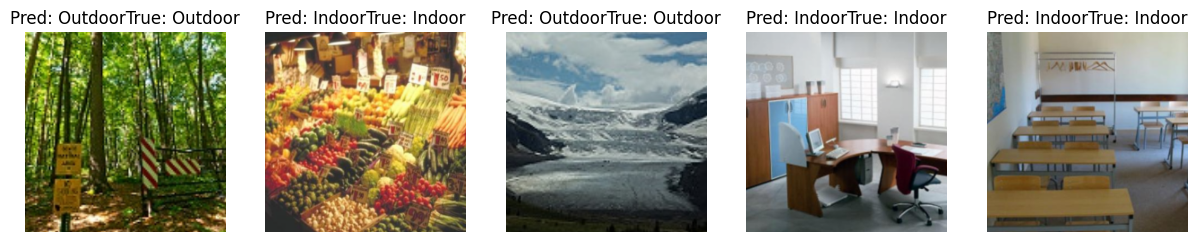

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

images, labels = next(iter(val_loader))
images = images[:5].to(device)
labels = labels[:5]

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

class_names = full_dataset.classes

print("===== KẾT QUẢ DỰ ĐOÁN =====")
for i in range(5):
    print(
        f"Ảnh {i+1}: Dự đoán = {class_names[predicted[i].item()]} | "
        f"Thực tế = {class_names[labels[i].item()]}"
    )

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i in range(5):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    pred = class_names[predicted[i].item()]
    true = class_names[labels[i].item()]

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Pred: {pred}True: {true}")

plt.show()

In [27]:
torch.save(model.state_dict(), "alexnet_transfer_learning.pth")
print("Saved: alexnet_transfer_learning.pth")

Saved: alexnet_transfer_learning.pth
